In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

In [16]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [6]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [7]:
df_exploded = df.explode('job_skills')

In [8]:
df_INDIA = df_exploded[df_exploded['job_country'] == 'India']
df_skills_count = df_INDIA.groupby(['job_title_short' , 'job_skills']).size()

In [9]:
df_skills_count = df_skills_count.reset_index(name='skill_count')


In [10]:
df_skills_count = df_skills_count.sort_values(by='skill_count', ascending= False)
df_skills_count

,job_title_short,job_skills,skill_count
637,Data Engineer,sql,12993
603,Data Engineer,python,11568
807,Data Scientist,python,9248
632,Data Engineer,spark,7157
480,Data Engineer,aws,6993
...,...,...,...
25,Business Analyst,dart,1
27,Business Analyst,datarobot,1
30,Business Analyst,django,1
32,Business Analyst,drupal,1


In [11]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles
df_skills_count

,job_title_short,job_skills,skill_count
637,Data Engineer,sql,12993
603,Data Engineer,python,11568
807,Data Scientist,python,9248
632,Data Engineer,spark,7157
480,Data Engineer,aws,6993
...,...,...,...
25,Business Analyst,dart,1
27,Business Analyst,datarobot,1
30,Business Analyst,django,1
32,Business Analyst,drupal,1


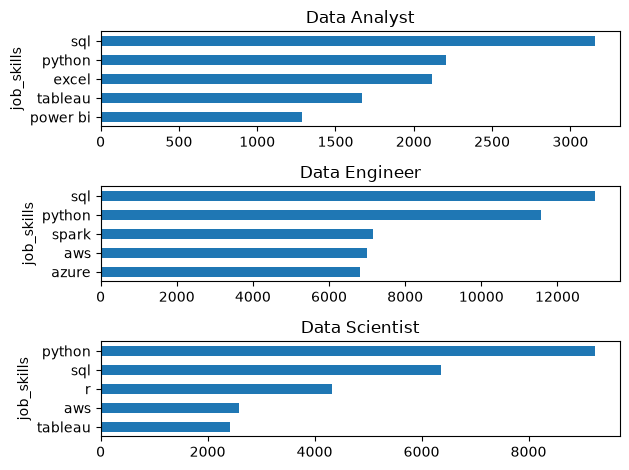

In [12]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    job_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head()
    job_plot.plot(kind= 'barh' , x= 'job_skills', y= 'skill_count'  ,ax= ax[i], title = job_title, legend= False)
    ax[i].invert_yaxis()
    fig.tight_layout()

In [13]:
df_total = df[df['job_country'] == 'India']['job_title_short'].value_counts().reset_index(name= 'total_jobs')

In [14]:
skill_perc = pd.merge(df_skills_count , df_total , how= 'left' , on= 'job_title_short')

skill_perc['skill_percentage'] = 100 * skill_perc['skill_count'] / skill_perc['total_jobs']
skill_perc

,job_title_short,job_skills,skill_count,total_jobs,skill_percentage
0,Data Engineer,sql,12993,19062,68.161788
1,Data Engineer,python,11568,19062,60.686182
2,Data Scientist,python,9248,13279,69.643798
3,Data Engineer,spark,7157,19062,37.545903
4,Data Engineer,aws,6993,19062,36.685552
...,...,...,...,...,...
1684,Business Analyst,dart,1,1887,0.052994
1685,Business Analyst,datarobot,1,1887,0.052994
1686,Business Analyst,django,1,1887,0.052994
1687,Business Analyst,drupal,1,1887,0.052994


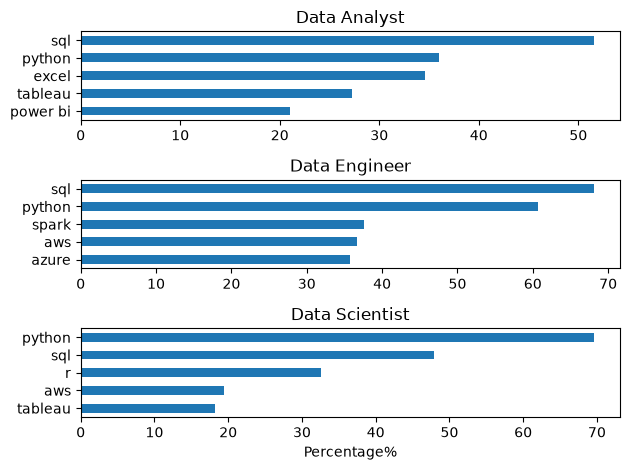

In [15]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    job_plot = skill_perc[skill_perc['job_title_short'] == job_title].head()
    job_plot.plot(kind= 'barh' , x= 'job_skills', y= 'skill_percentage'  ,ax= ax[i], title = job_title, legend= False)
    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    if i == 2:
      ax[i].set_xlabel("Percentage%")


    fig.tight_layout()